# Phase 1, Step 7 — The chronological split

Last step of Phase 1. It sounds trivial — cut the data into train, validation
and test — and it is the step where more ML projects silently ruin themselves
than any other.

**Three separate leaks have to be closed here:**

1. **Time order.** A shuffled split lets the model train on minute 15 of a flare
   and be tested on minute 14. It has effectively seen the answer.
2. **Window overlap.** Your windows are 30 min long, cut every 60 s, so
   neighbours share 29 of 30 minutes. Even a *chronological* split leaks at the
   boundary: the last train window and the first test window are 97% identical.
3. **Event bleed.** One flare produces ~30 windows. If some land in train and
   some in test, you are testing on an event the model already saw. This one
   survives both fixes above and has to be handled explicitly.

The output is a split you can defend, plus an honest count of how many
*independent events* — not windows — each part actually contains.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("../data") if Path("../data").exists() else Path("data")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
TR, VA, TE = "#2c7fb8", "#e67e22", "#c0392b"

z = np.load(DATA / "windows.npz", allow_pickle=False)
X          = z["X"]
t_end      = pd.to_datetime(z["t_end"])
y_prog     = z["y_progress"]
y_cls      = z["y_class"]
y_warn     = z["y_warn"]
warn_start = z["warn_started"]
FEATURES   = [str(f) for f in z["features"]]

# The configuration travels with the data, so this notebook needs no guessing.
CADENCE, WINDOW_MIN, STRIDE_S, HORIZON_MIN, LABEL_SCHEME, K_EFOLD = z["meta"]
WINDOW_MIN = int(WINDOW_MIN)
K_EFOLD    = float(K_EFOLD)
EFOLD_MIN  = 12.6

fl = pd.read_parquet(DATA / "flares.parquet")
for c in ["event_starttime", "event_peaktime", "event_endtime"]:
    fl[c] = pd.to_datetime(fl[c])
fl = fl.sort_values("event_starttime").reset_index(drop=True)
CLS = {"A": 0, "B": 0, "C": 1, "M": 2, "X": 3}
fl["cls_id"] = fl["class_letter"].map(CLS).fillna(0).astype(int)

print(f"windows   : {len(X):,}   shape {X.shape}")
print(f"features  : {FEATURES}")
print(f"config    : window {WINDOW_MIN} min, stride {STRIDE_S}s, "
      f"label '{LABEL_SCHEME}' K={K_EFOLD}, horizon {HORIZON_MIN} min")
print(f"span      : {t_end[0]}  ->  {t_end[-1]}")

windows   : 9,959   shape (9959, 180, 6)
features  : ['log_xrsb', 'log_xrsa', 'log_ratio', 'hardness', 'rate_smooth', 'rate_a']
config    : window 30 min, stride 60s, label 'efold' K=2.0, horizon 10 min
span      : 2024-08-01 00:38:50  ->  2024-08-07 23:59:50


## 1. Why shuffling would destroy this

Do not take this on faith — measure it. Below, a random 70/30 split is made and
then, for every test window, the *nearest train window in time* is found. If
that distance is under one window length, the two share raw samples.

In [2]:
rng = np.random.default_rng(0)
perm = rng.permutation(len(t_end))
cut = int(0.7 * len(t_end))
tr_r, te_r = perm[:cut], perm[cut:]

tr_t = np.sort(t_end[tr_r].values.astype("int64"))
te_t = t_end[te_r].values.astype("int64")
W_NS = WINDOW_MIN * 60 * 1_000_000_000

pos = np.searchsorted(tr_t, te_t)
left  = np.where(pos > 0,        te_t - tr_t[np.clip(pos-1, 0, len(tr_t)-1)], np.iinfo(np.int64).max)
right = np.where(pos < len(tr_t), tr_t[np.clip(pos, 0, len(tr_t)-1)] - te_t,  np.iinfo(np.int64).max)
nearest = np.minimum(left, right)

shared = (nearest < W_NS).mean()
print("RANDOM SPLIT (the wrong way)")
print(f"  test windows sharing raw samples with a train window: {100*shared:.1f}%")
print(f"  median gap to nearest train window: {np.median(nearest)/1e9/60:.1f} min "
      f"(window is {WINDOW_MIN} min)")
print()
print("Every one of those test windows is partly memorised. A model can score")
print("beautifully on this split and be worthless in deployment.")

RANDOM SPLIT (the wrong way)
  test windows sharing raw samples with a train window: 100.0%
  median gap to nearest train window: 1.0 min (window is 30 min)

Every one of those test windows is partly memorised. A model can score
beautifully on this split and be worthless in deployment.


## 2. Attach each window to a flare event

To stop event bleed you first need to know which flare each window belongs to.
A window is assigned to the flare whose labelled interval contains its end
timestamp; where intervals overlap, the most recently started flare wins.

`event_id = -1` means quiet Sun.

In [3]:
def label_end(f):
    if LABEL_SCHEME == "catalogued":
        return f["event_endtime"]
    return f["event_peaktime"] + pd.Timedelta(minutes=K_EFOLD * EFOLD_MIN)


event_id = np.full(len(t_end), -1, dtype=np.int32)
te_ns = t_end.values.astype("int64")

for i, f in fl.iterrows():                       # ascending start -> later wins
    s = np.datetime64(f["event_starttime"]).astype("datetime64[ns]").astype("int64")
    e = np.datetime64(label_end(f)).astype("datetime64[ns]").astype("int64")
    event_id[(te_ns >= s) & (te_ns <= e)] = i

n_ev = len(np.unique(event_id[event_id >= 0]))
print(f"windows attached to a flare : {(event_id >= 0).sum():,}")
print(f"distinct flares represented : {n_ev} of {len(fl)}")
print(f"quiet-Sun windows           : {(event_id < 0).sum():,}")
print()
per = pd.Series(event_id[event_id >= 0]).value_counts()
print(f"windows per flare: median {per.median():.0f}, min {per.min()}, max {per.max()}")
print()
print("THIS is your real sample size. Windows from one flare are near-duplicates,")
print("not independent observations.")

windows attached to a flare : 2,927
distinct flares represented : 92 of 95
quiet-Sun windows           : 7,032

windows per flare: median 32, min 5, max 71

THIS is your real sample size. Windows from one flare are near-duplicates,
not independent observations.


## 3. Put the boundaries in quiet gaps

If a boundary falls mid-flare, that flare's windows are split across two sets —
event bleed, by construction. So instead of cutting at an arbitrary 70% mark,
find the flare-free intervals and cut inside the one nearest the target.

Each flare is padded by one window length on both sides, because a window
ending up to `WINDOW_MIN` after a flare still *contains* that flare.

In [4]:
def free_intervals(fl, t0, t1, pad_min):
    """Stretches of [t0,t1] untouched by any flare (plus padding)."""
    pad = pd.Timedelta(minutes=pad_min)
    busy = sorted((f["event_starttime"] - pad, label_end(f) + pad)
                  for _, f in fl.iterrows())
    merged = []
    for s, e in busy:
        if merged and s <= merged[-1][1]:
            merged[-1] = (merged[-1][0], max(merged[-1][1], e))
        else:
            merged.append([s, e])
    free, cur = [], t0
    for s, e in merged:
        if s > cur:
            free.append((cur, min(s, t1)))
        cur = max(cur, e)
        if cur >= t1:
            break
    if cur < t1:
        free.append((cur, t1))
    return [(a, b) for a, b in free if b > a]


def pick_boundary(target, free):
    """Midpoint of the flare-free interval nearest the target time."""
    if not free:
        raise RuntimeError("no flare-free interval -- widen the date range")
    best = min(free, key=lambda ab: min(abs((ab[0]-target).total_seconds()),
                                        abs((ab[1]-target).total_seconds())))
    return best[0] + (best[1] - best[0]) / 2


free = free_intervals(fl, t_end[0], t_end[-1], pad_min=WINDOW_MIN)
tot = sum((b-a).total_seconds() for a, b in free) / 3600
print(f"flare-free intervals: {len(free)}  totalling {tot:.1f} h "
      f"of {(t_end[-1]-t_end[0]).total_seconds()/3600:.1f} h")

span = t_end[-1] - t_end[0]
b_tr = pick_boundary(t_end[0] + 0.70 * span, free)
b_va = pick_boundary(t_end[0] + 0.85 * span, free)
print()
print(f"train | val boundary : {b_tr}")
print(f"val   | test boundary: {b_va}")

flare-free intervals: 37  totalling 64.8 h of 167.3 h

train | val boundary : 2024-08-05 22:02:36
val   | test boundary: 2024-08-06 23:32:36


## 4. Assign, with an exclusion band

Windows whose end falls within `WINDOW_MIN` *after* a boundary are dropped
entirely. Those are exactly the windows that still contain pre-boundary
samples — the overlap leak. Discarding a few hundred windows is a small price
for a test score that means something.

In [5]:
gap = pd.Timedelta(minutes=WINDOW_MIN)

is_tr = t_end <= b_tr
is_va = (t_end > b_tr + gap) & (t_end <= b_va)
is_te = t_end > b_va + gap
dropped = ~(is_tr | is_va | is_te)

print(f"train   : {is_tr.sum():,}")
print(f"val     : {is_va.sum():,}")
print(f"test    : {is_te.sum():,}")
print(f"dropped : {dropped.sum():,}  (inside the {WINDOW_MIN}-min exclusion bands)")
print()
for nm, msk in [("train", is_tr), ("val", is_va), ("test", is_te)]:
    print(f"  {nm:<5} {t_end[msk][0]}  ->  {t_end[msk][-1]}")

train   : 6,961
val     : 1,500
test    : 1,438
dropped : 60  (inside the 30-min exclusion bands)

  train 2024-08-01 00:38:50  ->  2024-08-05 22:01:50
  val   2024-08-05 22:32:50  ->  2024-08-06 23:31:50
  test  2024-08-07 00:02:50  ->  2024-08-07 23:59:50


In [6]:
# --- Verification. These assertions are the point of the whole notebook. ---
print("LEAKAGE CHECKS")

g1 = (t_end[is_va][0] - t_end[is_tr][-1]).total_seconds() / 60
g2 = (t_end[is_te][0] - t_end[is_va][-1]).total_seconds() / 60
print(f"  gap train->val  : {g1:.1f} min  (need > {WINDOW_MIN})")
print(f"  gap val->test   : {g2:.1f} min  (need > {WINDOW_MIN})")
assert g1 > WINDOW_MIN and g2 > WINDOW_MIN, "boundary gap too small -- windows overlap"

e_tr = set(event_id[is_tr][event_id[is_tr] >= 0])
e_va = set(event_id[is_va][event_id[is_va] >= 0])
e_te = set(event_id[is_te][event_id[is_te] >= 0])
print(f"  events shared train/val : {len(e_tr & e_va)}")
print(f"  events shared train/test: {len(e_tr & e_te)}")
print(f"  events shared val/test  : {len(e_va & e_te)}")
assert not (e_tr & e_va) and not (e_tr & e_te) and not (e_va & e_te), "event bleed"

print()
print("  PASS -- no shared samples, no shared events.")

LEAKAGE CHECKS
  gap train->val  : 31.0 min  (need > 30)
  gap val->test   : 31.0 min  (need > 30)
  events shared train/val : 0
  events shared train/test: 0
  events shared val/test  : 0

  PASS -- no shared samples, no shared events.


## 5. What each split actually contains

Two counts per split. The window count is what you feed the model; the
**event count is your statistical power.** Quote the second one whenever you
report a metric.

In [7]:
rows = []
for nm, msk, ev in [("train", is_tr, e_tr), ("val", is_va, e_va), ("test", is_te, e_te)]:
    mp = fl.loc[sorted(ev), "cls_id"] if ev else pd.Series(dtype=int)
    rows.append({
        "split": nm,
        "windows": int(msk.sum()),
        "events": len(ev),
        "C": int((mp == 1).sum()), "M": int((mp == 2).sum()), "X": int((mp == 3).sum()),
        "flare_win_%": round(100 * y_prog[msk].mean(), 1),
        "warn_win_%": round(100 * y_warn[msk].mean(), 2),
    })
summary = pd.DataFrame(rows).set_index("split")
print(summary.to_string())
print()
print("Read the 'events' column, not 'windows'. That is what your error bars use.")

       windows  events   C   M  X  flare_win_%  warn_win_%
split                                                     
train     6961      73  28  43  2         33.2        6.36
val       1500       9   8   1  0         19.7        0.67
test      1438      10   6   4  0         22.3        2.78

Read the 'events' column, not 'windows'. That is what your error bars use.


In [8]:
def wilson(k, n, z=1.96):
    """Wilson score interval -- correct for small n, unlike the normal approx."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    d = 1 + z*z/n
    c = (p + z*z/(2*n)) / d
    h = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / d
    return (max(0.0, c-h), min(1.0, c+h))


n_te = len(e_te)
print(f"Test set holds {n_te} independent flare events.")
print()
print("If your model recalls this fraction of them, the 95% interval is:")
for r in [0.6, 0.7, 0.8, 0.9, 1.0]:
    k = int(round(r * n_te))
    lo, hi = wilson(k, n_te)
    print(f"  recall {r:.0%}  ({k}/{n_te})  ->  [{lo:.0%}, {hi:.0%}]   width {100*(hi-lo):.0f} pts")
print()
print("Report the interval, or at least the event count, beside every metric.")
print("Extending to five months is what shrinks these.")

Test set holds 10 independent flare events.

If your model recalls this fraction of them, the 95% interval is:
  recall 60%  (6/10)  ->  [31%, 83%]   width 52 pts
  recall 70%  (7/10)  ->  [40%, 89%]   width 50 pts
  recall 80%  (8/10)  ->  [49%, 94%]   width 45 pts
  recall 90%  (9/10)  ->  [60%, 98%]   width 39 pts
  recall 100%  (10/10)  ->  [72%, 100%]   width 28 pts

Report the interval, or at least the event count, beside every metric.
Extending to five months is what shrinks these.


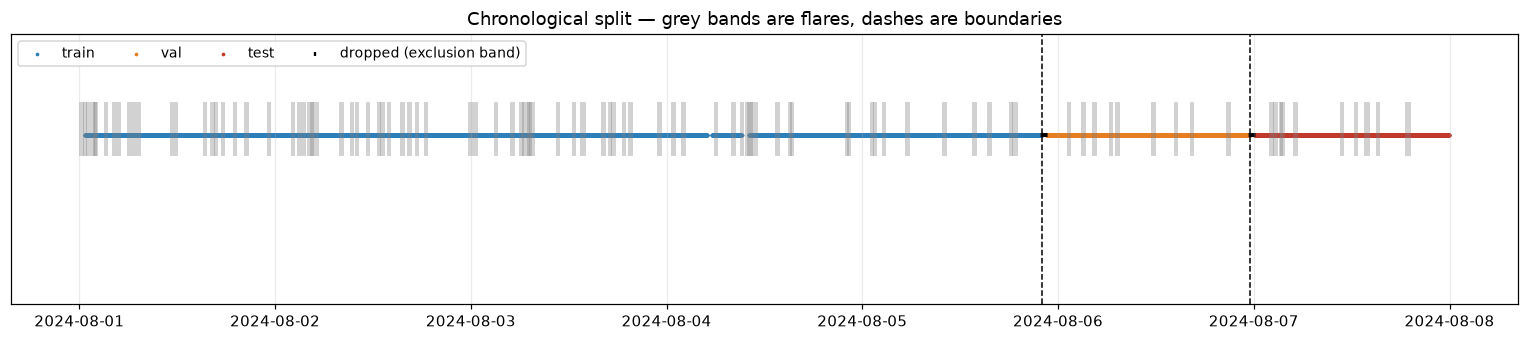

In [9]:
fig, ax = plt.subplots(figsize=(14, 3.2))
for nm, msk, col in [("train", is_tr, TR), ("val", is_va, VA), ("test", is_te, TE)]:
    ax.scatter(t_end[msk], np.full(msk.sum(), 1), s=2, color=col, label=nm)
ax.scatter(t_end[dropped], np.full(dropped.sum(), 1), s=6, color="black",
           marker="|", label="dropped (exclusion band)")
for b in [b_tr, b_va]:
    ax.axvline(b, color="black", ls="--", lw=1)
for _, f in fl.iterrows():
    ax.axvspan(f["event_starttime"], label_end(f), ymin=0.55, ymax=0.75,
               color="gray", alpha=0.35, lw=0)
ax.set_yticks([]); ax.set_ylim(0.5, 1.3)
ax.legend(loc="upper left", ncol=4, fontsize=9)
ax.set_title("Chronological split — grey bands are flares, dashes are boundaries")
plt.tight_layout(); plt.show()

## 6. Normalisation — fit on train only

Neural networks want inputs on a comparable scale. The trap is subtle: fit the
scaler on *all* the data and the training set has absorbed the mean and standard
deviation of the test set. That is leakage, it inflates your score, and it is
completely invisible.

Statistics come from **train alone** and are then applied unchanged to val and
test — exactly as they will be applied to live data in deployment.

In [10]:
F = X.shape[2]
flat = X[is_tr].reshape(-1, F)
mu = flat.mean(axis=0)
sd = flat.std(axis=0)
sd[sd < 1e-8] = 1.0                       # never divide by ~0

print(f"{'feature':<14}{'mean':>10}{'std':>10}")
for f, a, b in zip(FEATURES, mu, sd):
    print(f"{f:<14}{a:>10.4f}{b:>10.4f}")

Xn = ((X - mu) / sd).astype(np.float32)

print()
print("after scaling (train rows):")
tr_flat = Xn[is_tr].reshape(-1, F)
print(f"  mean {tr_flat.mean():+.4f}   std {tr_flat.std():.4f}   (expect ~0 and ~1)")
te_flat = Xn[is_te].reshape(-1, F)
print(f"  test mean {te_flat.mean():+.4f}   std {te_flat.std():.4f}")
print("  test statistics need NOT be 0/1 -- if they were, the scaler saw the test set.")

feature             mean       std
log_xrsb         -5.2002    0.2810
log_xrsa         -6.5718    0.5203
log_ratio         0.1848    0.2478
hardness         -1.3967    0.2527
rate_smooth      -0.0000    0.0046
rate_a           -0.0000    0.0107

after scaling (train rows):
  mean +0.0069   std 1.0005   (expect ~0 and ~1)
  test mean -0.2476   std 0.8526
  test statistics need NOT be 0/1 -- if they were, the scaler saw the test set.


## 7. Save

In [11]:
out = DATA / "dataset.npz"
np.savez_compressed(
    out,
    X=Xn,
    t_end=t_end.values.astype("datetime64[ns]"),
    y_progress=y_prog, y_class=y_cls, y_warn=y_warn, warn_started=warn_start,
    event_id=event_id,
    is_train=is_tr.values if hasattr(is_tr, "values") else is_tr,
    is_val=is_va.values if hasattr(is_va, "values") else is_va,
    is_test=is_te.values if hasattr(is_te, "values") else is_te,
    scaler_mean=mu, scaler_std=sd,
    features=np.array(FEATURES),
    meta=np.array([CADENCE, str(WINDOW_MIN), str(STRIDE_S), str(HORIZON_MIN),
                   LABEL_SCHEME, str(K_EFOLD), str(b_tr), str(b_va)]),
)
print(f"Saved -> {out}  ({out.stat().st_size/1e6:.1f} MB)")
chk = np.load(out, allow_pickle=False)
for k in chk.files:
    print(f"  {k:<13} {str(chk[k].shape):<20} {chk[k].dtype}")

Saved -> ..\data\dataset.npz  (1.7 MB)
  X             (9959, 180, 6)       float32
  t_end         (9959,)              datetime64[ns]
  y_progress    (9959,)              int8
  y_class       (9959,)              int8
  y_warn        (9959,)              int8
  warn_started  (9959,)              int8
  event_id      (9959,)              int32
  is_train      (9959,)              bool
  is_val        (9959,)              bool
  is_test       (9959,)              bool
  scaler_mean   (6,)                 float32
  scaler_std    (6,)                 float32
  features      (6,)                 <U11
  meta          (8,)                 <U19


## 8. Phase 1 complete

`dataset.npz` is model-ready: scaled features, three label sets, split masks,
event IDs, and the scaler parameters needed to transform live data identically
in deployment.

**Four leaks closed, each verified rather than asserted:**

| Leak | Fix | Check |
|---|---|---|
| future in features | backward diffs, trailing windows | truncation test in Step 6 |
| shuffled time order | chronological split | §1 measurement |
| overlapping windows | exclusion band | gap assertion |
| shared events | boundaries in quiet gaps | set-intersection assertion |
| scaler saw test | fit on train only | test stats are not 0/1 |

**Then the thing that matters most:** change the two dates in `config.py` and
re-run notebooks 02 → 07 for five months. Every measurement so far rests on 95
flares and 2 X-class events. The pipeline is built; it now needs data
proportionate to it.

**Phase 2** is the threshold baseline — a detector using only `log_ratio` and a
cutoff, scored with TSS and HSS on this same test split. It should take an hour,
and until a learned model beats it, that model is not earning its complexity.